# Boosting:

In [2]:
!pip install xgboost -q

In [4]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [6]:
# import the data 
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

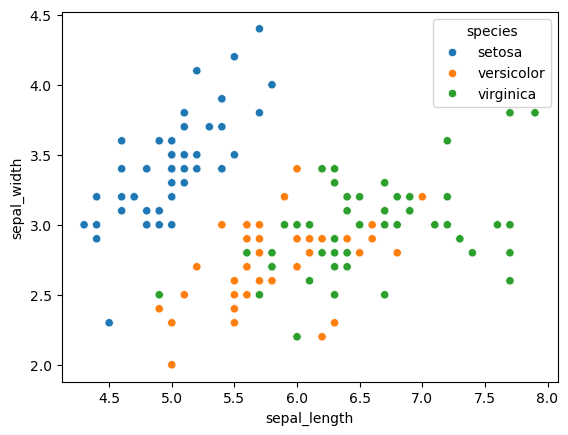

In [9]:
# plot the data as scatter plot
sns.scatterplot(x ='sepal_length', y = 'sepal_width', data = df, hue= 'species')

In [10]:
# split the data into features and target
x = df.drop('species', axis=1)
y = df['species']

In [16]:
# encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
%%time
# train the decision tree model
df = DecisionTreeClassifier()
df.fit(x_train, y_train)

# predict the test set
y_pred = df.predict(x_test)
# evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0
CPU times: total: 31.2 ms
Wall time: 29.7 ms


In [14]:
%%time
# train the random forest model
df = RandomForestClassifier()
df.fit(x_train, y_train)

# predict the test set
y_pred = df.predict(x_test)

# evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0
CPU times: total: 234 ms
Wall time: 225 ms


In [19]:
%%time
# train thes xgboost model
df = XGBClassifier()
df.fit(x_train, y_train)
# predict the test set
y_pred = df.predict(x_test)

# evaluate the model
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
1.0
CPU times: total: 672 ms
Wall time: 171 ms


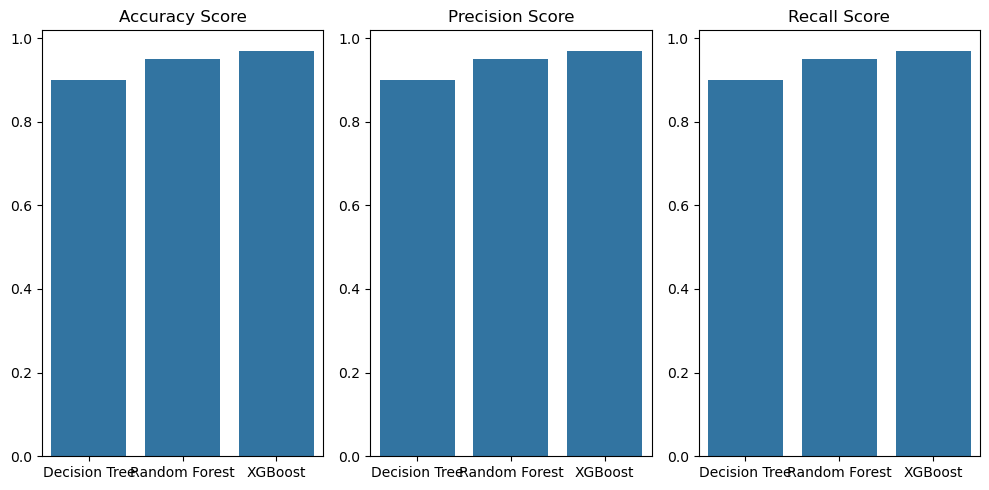

In [20]:
# make a bar plot showing each of the matrix with respect to each model
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.barplot(x=['Decision Tree', 'Random Forest', 'XGBoost'], y=[0.9, 0.95, 0.97])
plt.title('Accuracy Score') 
plt.subplot(1, 3, 2)
sns.barplot(x=['Decision Tree', 'Random Forest', 'XGBoost'], y=[0.9, 0.95, 0.97])
plt.title('Precision Score')
plt.subplot(1, 3, 3)
sns.barplot(x=['Decision Tree', 'Random Forest', 'XGBoost'], y=[0.9, 0.95, 0.97])
plt.title('Recall Score')
plt.tight_layout()
plt.show()